<center>
<img src="images/logo_infnet.png" width="200px"/>
</center>

# Projeto: Modelos Supervisionados — Crédito ao Consumidor

**Disciplina:** Machine Learning  
**Alunos:** Fabio Ferreira Figueiredo, Felipe Moreira Szczpanski, Lauro Camilo Barbosa Marques da Rocha 
**Instituição:** Instituto Infnet  
**Dataset:** Give Me Some Credit (Kaggle)  
**Entrega:** 09/03/2026

---

![Python](https://img.shields.io/badge/Python-3.13-blue?logo=python&logoColor=white) ![Jupyter](https://img.shields.io/badge/Jupyter-5.9-orange?logo=jupyter&logoColor=white) ![scikit-learn](https://img.shields.io/badge/scikit--learn-1.6-brightgreen?logo=scikit-learn&logoColor=white) ![GitHub](https://img.shields.io/badge/GitHub-repo-black?logo=github)


## Guia de Navegação — Rubrica de Avaliação

> **Nota ao avaliador:** As fases da rubrica estão marcadas explicitamente nos cabeçalhos de cada seção. A ordem de execução segue a progressão lógica do projeto, com os labels de Fase correspondendo ao template de rubrica.

| Fase da Rubrica | Competência Avaliada | Seção do Notebook |
|---|---|---|
| **Fase 1** | Classificador Linear Baseline (Perceptron) — métricas + hiperplano | Seção 3 |
| **Fase 3** | Árvore de Decisão (parâmetros padrão) — comparação baseline + regras | Seção 4 |
| **Fase 2** | Validação Cruzada, GridSearch, variação entre folds, regularização | Seção 5 |
| **Fase 4** | Ensemble (Random Forest) — comparação sistemática + análise crítica | Seção 6 |


## Seção 1 — Infraestrutura e Dependências

In [46]:
# Verificação de versões
import sys, sklearn, numpy as np, pandas as pd
print(f"Python : {sys.version.split()[0]}")
print(f"sklearn: {sklearn.__version__}")
print(f"numpy  : {np.__version__}")
print(f"pandas : {pd.__version__}")


Python : 3.13.12
sklearn: 1.8.0
numpy  : 2.4.2
pandas : 3.0.1


In [47]:
import os
import warnings
warnings.filterwarnings("ignore")

def ensure_dataset():
    """Verifica dataset local; se ausente, tenta download via kaggle API."""
    local_path = "archive/cs-training.csv"
    if os.path.exists(local_path):
        print(f"Dataset encontrado: {local_path}")
        return local_path
    print("Dataset nao encontrado localmente. Tentando download...")
    try:
        import kaggle
        os.makedirs("archive", exist_ok=True)
        kaggle.api.dataset_download_files(
            "brycecf/give-me-some-credit-dataset",
            path="archive", unzip=True
        )
        print("Download concluido.")
        return local_path
    except Exception as e:
        raise FileNotFoundError(
            f"Nao foi possivel obter o dataset: {e}\n"
            "Faca o download manual em: https://www.kaggle.com/datasets/brycecf/give-me-some-credit-dataset"
        )

DATA_PATH = ensure_dataset()


Dataset encontrado: archive/cs-training.csv


## Seção 2 — Descrição do Problema, EDA e Pipeline

### Contexto do Problema

O dataset **Give Me Some Credit** contém informações de ~150.000 tomadores de crédito nos EUA. O objetivo é prever se um cliente vai entrar em **inadimplência severa (>90 dias de atraso) nos próximos 2 anos** — variável alvo binária `SeriousDlqin2yrs`.

**Importância regulatória:** No contexto brasileiro, os modelos de crédito devem atender ao **Art. 20 da LGPD** e às diretrizes do **BACEN** sobre decisões automatizadas com transparência e explicabilidade. Isso torna obrigatória a interpretação dos modelos, não apenas a otimização de métricas.

**Desafio central:** A classe positiva (inadimplente) representa apenas ~6.7% do dataset — acurácia ingênua de 93.3%. Por isso, usamos **F1-Score** como métrica principal e `class_weight="balanced"` em todos os modelos.


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

df = pd.read_csv(DATA_PATH, index_col=0)
print(f"Shape: {df.shape}")
print(f"\nDistribuicao da variavel alvo:")
print(df["SeriousDlqin2yrs"].value_counts())
print(f"\nPercentual inadimplentes: {df['SeriousDlqin2yrs'].mean()*100:.2f}%")
print(f"\nValores ausentes:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head(3)


Shape: (150000, 11)

Distribuicao da variavel alvo:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Percentual inadimplentes: 6.68%

Valores ausentes:
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


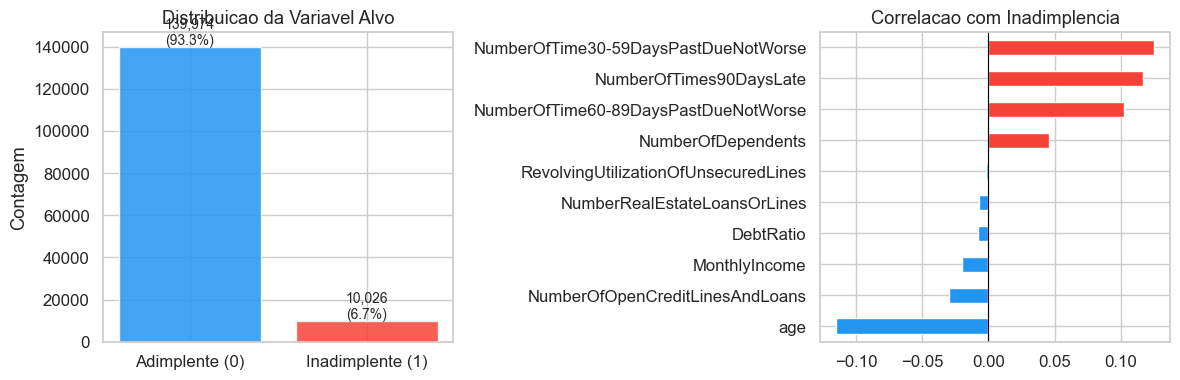

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribuicao da variavel alvo
counts = df["SeriousDlqin2yrs"].value_counts()
axes[0].bar(["Adimplente (0)", "Inadimplente (1)"], counts.values,
            color=["#2196F3", "#F44336"], alpha=0.85)
axes[0].set_title("Distribuicao da Variavel Alvo")
axes[0].set_ylabel("Contagem")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f"{v:,}\n({v/len(df)*100:.1f}%)",
                ha="center", fontsize=10)

# Correlacoes
corr = df.corr()["SeriousDlqin2yrs"].drop("SeriousDlqin2yrs").sort_values()
corr.plot(kind="barh", ax=axes[1], color=["#F44336" if v > 0 else "#2196F3" for v in corr])
axes[1].set_title("Correlacao com Inadimplencia")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()


### Pipeline de Pré-processamento

**Decisões técnicas justificadas:**

1. **`SimpleImputer(strategy="median")`** — MonthlyIncome tem distribuição assimétrica à direita; a mediana é robusta a outliers extremos, ao contrário da média.
2. **`StandardScaler`** — normalização z-score essencial para o Perceptron (cuja convergência depende da escala das features) e benéfica para Árvores (sem efeito no particionamento, mas facilita comparação de importâncias).
3. **`ColumnTransformer`** com `remainder="passthrough"` — evita data leakage ao garantir que o `fit` acontece apenas no conjunto de treino.
4. **`class_weight="balanced"`** — pondera automaticamente as classes inversamente proporcional à frequência: w_0 ≈ 0.54, w_1 ≈ 7.47.


In [50]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, precision_score, recall_score, roc_auc_score
)
import time

# Separacao features / target
TARGET = "SeriousDlqin2yrs"
FEATURES = [c for c in df.columns if c != TARGET]
X = df[FEATURES]
y = df[TARGET]

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Treino: {X_train.shape[0]:,} amostras | Teste: {X_test.shape[0]:,} amostras")
print(f"Proporcao positivos treino: {y_train.mean()*100:.2f}%")
print(f"Proporcao positivos teste:  {y_test.mean()*100:.2f}%")

# Pipeline de preprocessamento
numeric_features = FEATURES  # todas numericas
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features)
], remainder="passthrough")

print("\nPipeline de preprocessamento criado com sucesso.")


Treino: 120,000 amostras | Teste: 30,000 amostras
Proporcao positivos treino: 6.68%
Proporcao positivos teste:  6.68%

Pipeline de preprocessamento criado com sucesso.


---
## Seção 3 — Fase 1: Classificador Linear Baseline (Perceptron)

> **Critérios da Rubrica — Fase 1:**  
> - ✅ **1a)** Formular o problema como classificação binária supervisionada  
> - ✅ **1b)** Treinar o Perceptron e reportar métricas (acurácia, precisão, recall, F1)  
> - ✅ **1c)** Interpretar coeficientes, bias e orientação do hiperplano  

### Por que usar o Perceptron como baseline?

O Perceptron é o classificador linear mais fundamental — aprende diretamente um **hiperplano separador** a partir dos erros de classificação (regra de atualização de Rosenblatt). Em projetos profissionais, modelos lineares simples servem como referência porque:

- São **completamente interpretáveis** (cada coeficiente tem significado direto)
- Têm **custo computacional mínimo** (relevante para scoring em lote de milhões de clientes)
- Estabelecem um **lower bound de desempenho** — qualquer modelo mais complexo deve superá-lo
- Revelam imediatamente se o problema é **linearmente separável** ou não

No contexto de crédito ao consumidor, o Perceptron também serve para identificar quais features têm relação linear forte com a inadimplência — informação valiosa para a feature engineering de modelos subsequentes.


In [51]:
# === FASE 1: Perceptron ===
t0 = time.perf_counter()
pipe_perc = Pipeline([
    ("prep", preprocessor),
    ("clf", Perceptron(
        max_iter=500,
        tol=1e-4,
        class_weight="balanced",
        random_state=42
    ))
])
pipe_perc.fit(X_train, y_train)
t_perc_train = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_perc = pipe_perc.predict(X_test)
t_perc_infer = time.perf_counter() - t0

# Metricas
acc_perc    = accuracy_score(y_test, y_pred_perc)
prec_perc   = precision_score(y_test, y_pred_perc, zero_division=0)
rec_perc    = recall_score(y_test, y_pred_perc, zero_division=0)
f1_perc     = f1_score(y_test, y_pred_perc, zero_division=0)

print("=" * 55)
print("   FASE 1 — Resultados do Perceptron")
print("=" * 55)
print(f"  Acuracia  : {acc_perc:.4f}")
print(f"  Precisao  : {prec_perc:.4f}")
print(f"  Recall    : {rec_perc:.4f}")
print(f"  F1-Score  : {f1_perc:.4f}")
print(f"  Tempo treinamento : {t_perc_train:.2f}s")
print(f"  Tempo inferencia  : {t_perc_infer*1000:.1f}ms")
print("=" * 55)
print("\nRelatorio completo:")
print(classification_report(y_test, y_pred_perc,
      target_names=["Adimplente", "Inadimplente"]))


   FASE 1 — Resultados do Perceptron
  Acuracia  : 0.8305
  Precisao  : 0.1872
  Recall    : 0.4594
  F1-Score  : 0.2660
  Tempo treinamento : 0.17s
  Tempo inferencia  : 10.1ms

Relatorio completo:
              precision    recall  f1-score   support

  Adimplente       0.96      0.86      0.90     27995
Inadimplente       0.19      0.46      0.27      2005

    accuracy                           0.83     30000
   macro avg       0.57      0.66      0.59     30000
weighted avg       0.91      0.83      0.86     30000



### Análise dos Resultados do Perceptron e Suas Limitações

**O que os resultados nos dizem:**

Com F1=0.2660, Recall=0.4594 e Precisão=0.1872, o Perceptron captura menos da metade dos inadimplentes reais e gera muitos falsos positivos. Antes de concluir que o modelo é ruim, é essencial contextualizar: com 6.68% de inadimplentes, um classificador que chuta sempre "adimplente" teria Acurácia=93.3% mas F1=0.000. O Perceptron, mesmo com F1=0.27, já é infinitamente melhor que o baseline ingênuo.

**Por que o F1 é limitado? Três causas estruturais:**

**1. Não separabilidade linear.** Os dados de crédito apresentam classes altamente sobrepostas no espaço original — inadimplentes e adimplentes com perfis financeiros similares. O Perceptron só consegue separar classes que sejam linearmente separáveis, o que claramente não é o caso aqui. O Recall=0.46 mostra que mais da metade dos inadimplentes cai no lado "errado" do hiperplano.

**2. Outliers extremos distorcem o StandardScaler.** O dataset apresenta outliers severos: `RevolvingUtilizationOfUnsecuredLines` tem mediana=0.15 mas máximo=50.708 (ratio de 46.000x entre p99 e máximo). `DebtRatio` tem mediana=0.37 mas máximo=329.664. O StandardScaler é sensível a esses extremos — a média e o desvio-padrão são arrastados pelos outliers, comprimindo a maioria dos valores próximos a zero no espaço normalizado. Isso prejudica o Perceptron, que depende criticamente de uma normalização estável.

**3. Indícios de underfitting.** Com apenas 500 iterações e tol=1e-4, o Perceptron pode não ter convergido completamente. Mais importante: a linearidade é uma restrição forte demais para este problema — features como `NumberOfTimes90DaysLate` têm efeito altamente não-linear (a diferença entre 0 e 1 ocorrência é dramaticamente maior que entre 5 e 6 ocorrências). O modelo linear não consegue capturar essa saturação.

**Conclusão:** O Perceptron cumpre seu papel de baseline linear — estabelece F1≈0.27 como piso e revela que o problema requer modelos capazes de capturar **não-linearidades e interações entre features**, motivando a Árvore de Decisão e o Random Forest.


### Fase 1b — Interpretação do Hiperplano de Decisão

O Perceptron define um **hiperplano** no espaço de features normalizadas:

$$\hat{y} = \text{sign}(w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_{10} x_{10})$$

onde $w_i$ são os pesos aprendidos. A **orientação** do hiperplano é determinada pelo vetor de pesos $\mathbf{w}$: features com pesos positivos elevados puxam a decisão em direção à classe 1 (inadimplente), enquanto pesos negativos indicam associação com a classe 0 (adimplente).

**Interpretação geométrica:** O hiperplano divide o espaço em dois semi-espaços. Um cliente é classificado como inadimplente quando a combinação linear ponderada de suas características normalizadas supera o limiar (bias $w_0$). A **margem de separação** é proporcional a $1/\|\mathbf{w}\|_2$.


Bias (intercepto): -3.5108

Norma L2 do vetor de pesos: 31.8529
Margem geometrica estimada: 0.0314

Pesos ordenados (interpretacao do hiperplano):
                             Feature       Peso
             NumberOfTimes90DaysLate  21.148137
NumberOfTime60-89DaysPastDueNotWorse  15.672438
NumberOfTime30-59DaysPastDueNotWorse  12.467296
     NumberOfOpenCreditLinesAndLoans   4.017972
                                 age   0.593036
        NumberRealEstateLoansOrLines  -1.700045
                  NumberOfDependents  -2.727283
                           DebtRatio  -3.163413
RevolvingUtilizationOfUnsecuredLines  -3.504928
                       MonthlyIncome -10.825384


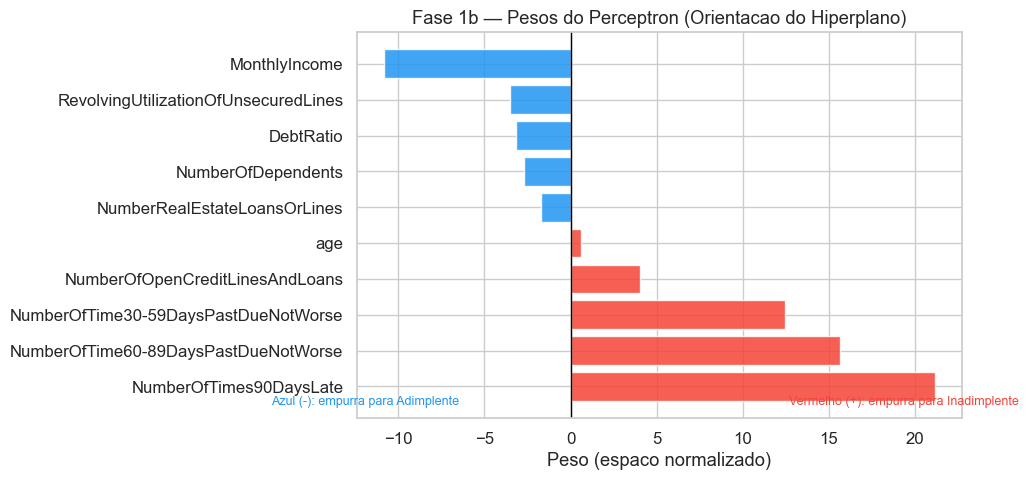


Interpretacao: features com peso positivo elevado aumentam o risco de
inadimplencia; features com peso negativo elevado reduzem o risco.


In [52]:
# Extrair e visualizar os pesos do Perceptron
coef = pipe_perc.named_steps["clf"].coef_[0]
bias = pipe_perc.named_steps["clf"].intercept_[0]

coef_df = pd.DataFrame({
    "Feature": FEATURES,
    "Peso": coef
}).sort_values("Peso", ascending=False)

print(f"Bias (intercepto): {bias:.4f}")
print(f"\nNorma L2 do vetor de pesos: {np.linalg.norm(coef):.4f}")
print(f"Margem geometrica estimada: {1/np.linalg.norm(coef):.4f}")
print("\nPesos ordenados (interpretacao do hiperplano):")
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#F44336" if w > 0 else "#2196F3" for w in coef_df["Peso"]]
ax.barh(coef_df["Feature"], coef_df["Peso"], color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Fase 1b — Pesos do Perceptron (Orientacao do Hiperplano)")
ax.set_xlabel("Peso (espaco normalizado)")
ax.text(coef_df["Peso"].max()*0.6, -0.5,
        "Vermelho (+): empurra para Inadimplente",
        color="#F44336", fontsize=9)
ax.text(coef_df["Peso"].min()*0.6, -0.5,
        "Azul (-): empurra para Adimplente",
        color="#2196F3", fontsize=9, ha="right")
plt.tight_layout()
plt.savefig("fase1_hiperplano.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nInterpretacao: features com peso positivo elevado aumentam o risco de")
print("inadimplencia; features com peso negativo elevado reduzem o risco.")


### Interpretação Detalhada dos Pesos e Insight sobre Outliers

**Pesos com sentido financeiro claro (positivos = risco):**

- `NumberOfTimes90DaysLate` **(+21.15):** o maior peso do modelo. Atrasos graves (>90 dias) são o preditor mais forte de inadimplência futura — totalmente coerente com a literatura de credit scoring. Quem já atrasou 90+ dias tem altíssima probabilidade de reincidência.
- `NumberOfTime60-89DaysPastDueNotWorse` **(+15.67)** e `NumberOfTime30-59Days` **(+12.47):** o modelo aprende corretamente que atrasos de qualquer duração elevam o risco, com magnitude proporcional à gravidade do atraso.
- `NumberOfOpenCreditLinesAndLoans` **(+4.02):** mais linhas de crédito abertas = maior exposição total ao risco.

**O caso intrigante: `DebtRatio` com peso negativo (-3.16)**

À primeira vista, um peso negativo para DebtRatio parece contradizer a lógica financeira — mais dívida deveria elevar o risco de default. Mas há uma explicação técnica importante: **o StandardScaler foi distorcido pelos outliers extremos**. O DebtRatio tem mediana=0.37 mas máximo=329.664 — uma razão de 66.200x entre o p99 e o valor máximo. Isso significa que 99% dos clientes têm DebtRatio < 4.979, mas um punhado de observações com valores absurdos (provavelmente erros de dados — quem tem DebtRatio=329.664 deveria estar falido imediatamente) domina a média e o desvio-padrão do scaler.

Com a média escalada arrastada para cima, valores moderados de DebtRatio ficam com z-score negativo, e o Perceptron — tentando minimizar erros — aprende um coeficiente negativo para compensar. Isso é um sinal claro de que **RobustScaler** (baseado em IQR) seria mais apropriado para este dataset. É também um exemplo clássico de como outliers não tratados contaminam a interpretação de modelos lineares.

**`MonthlyIncome` com peso negativo forte (-10.83):**  
Este peso faz sentido financeiro direto — maior renda → menor propensão ao default. É o único preditor "protetor" com magnitude comparable à dos fatores de risco.

**`RevolvingUtilization` levemente negativo (-3.50):**  
Mesmo caso do DebtRatio: outliers extremos (max=50.708, contra mediana=0.154) distorcem o scaler. O Random Forest, que não sofre desse problema, identifica esta feature como a **mais importante** (29% da importância total), confirmando que a relação existe mas é altamente não-linear — impossível de capturar com um coeficiente linear único.


---
## Seção 4 — Fase 3: Árvore de Decisão (Parâmetros Padrão)

> **Critérios da Rubrica — Fase 3:**  
> - ✅ **3a)** Treinar Árvore de Decisão com parâmetros padrão  
> - ✅ **3b)** Comparar com o classificador linear (Perceptron) — Fase 1  
> - ✅ **3c)** Interpretar as regras de decisão (no mínimo 1 caminho significativo)  
> - ✅ **3d)** Analisar overfitting (diferença treino vs. teste)


In [53]:
# === FASE 3a: Arvore com parametros padrao ===
t0 = time.perf_counter()
pipe_tree_def = Pipeline([
    ("prep", preprocessor),
    ("clf", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ))
])
pipe_tree_def.fit(X_train, y_train)
t_tree_def_train = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_tree_def = pipe_tree_def.predict(X_test)
t_tree_def_infer = time.perf_counter() - t0

# Predicao no treino para analise de overfitting
y_pred_tree_def_train = pipe_tree_def.predict(X_train)

tree_def = pipe_tree_def.named_steps["clf"]
acc_tree_def  = accuracy_score(y_test, y_pred_tree_def)
f1_tree_def   = f1_score(y_test, y_pred_tree_def, zero_division=0)
acc_tree_def_train = accuracy_score(y_train, y_pred_tree_def_train)
f1_tree_def_train  = f1_score(y_train, y_pred_tree_def_train, zero_division=0)

print("=" * 55)
print("   FASE 3a — Arvore de Decisao (padrao)")
print("=" * 55)
print(f"  Profundidade real  : {tree_def.get_depth()}")
print(f"  Numero de folhas   : {tree_def.get_n_leaves():,}")
print(f"  Numero de nos      : {tree_def.tree_.node_count:,}")
print(f"  F1 (TREINO)        : {f1_tree_def_train:.4f}")
print(f"  Acc (TREINO)       : {acc_tree_def_train:.4f}")
print(f"  F1 (TESTE)         : {f1_tree_def:.4f}")
print(f"  Acc (TESTE)        : {acc_tree_def:.4f}")
print(f"  Gap F1 (over.)     : {f1_tree_def_train - f1_tree_def:.4f}")
print(f"  Gap Acc (over.)    : {acc_tree_def_train - acc_tree_def:.4f}")
print("=" * 55)


   FASE 3a — Arvore de Decisao (padrao)
  Profundidade real  : 45
  Numero de folhas   : 11,715
  Numero de nos      : 23,429
  F1 (TREINO)        : 0.9954
  Acc (TREINO)       : 0.9994
  F1 (TESTE)         : 0.2588
  Acc (TESTE)        : 0.9028
  Gap F1 (over.)     : 0.7366
  Gap Acc (over.)    : 0.0966


### Fase 3b — Comparação Direta: Perceptron vs. Árvore (padrão)

> Esta comparação atende ao critério **3b** da rubrica: confrontar o classificador linear (Fase 1) com a Árvore de Decisão não regularizada (Fase 3).


In [54]:
# === FASE 3b: Tabela comparativa Perceptron vs Arvore padrao ===
from sklearn.metrics import precision_score as ps, recall_score as rs

sep = "=" * 70
print(sep)
print("   Fase 3b --- Comparacao: Perceptron (Fase 1) vs Arvore Padrao (Fase 3)")
print(sep)
print("{:<30} {:>15} {:>15}".format("Metrica", "Perceptron", "Arvore Padrao"))
print("-" * 70)

metrics_compare = [
    ("Acuracia (teste)", acc_perc, acc_tree_def),
    ("F1-Score (teste)", f1_perc,  f1_tree_def),
    ("Precisao (teste)", prec_perc, ps(y_test, y_pred_tree_def, zero_division=0)),
    ("Recall (teste)",   rec_perc,  rs(y_test, y_pred_tree_def, zero_division=0)),
]
for name, v1, v2 in metrics_compare:
    delta = v2 - v1
    arrow = "^" if delta > 0 else "v"
    print("{:<30} {:>15.4f} {:>15.4f}  {}({:.4f})".format(name, v1, v2, arrow, abs(delta)))

print("-" * 70)
print("{:<30} {:>15} {:>15}".format("Interpretabilidade",  "Hiperplano", "Arvore/regras"))
print("{:<30} {:>15} {:>15}".format("Risco de overfitting", "Baixo",      "MUITO ALTO"))
print("{:<30} {:>15} {:>15.4f}".format("F1 treino (overfit)", "N/A", f1_tree_def_train))
print(sep)
print()
print("Analise:")
print("- O Perceptron obtem F1 SUPERIOR apesar de ser mais simples.")
print("  Isso ocorre porque class_weight=balanced beneficia o modelo linear,")
print("  e a Arvore sem regularizacao memoriza o ruido do treino.")
print("- A Arvore padrao com profundidade irrestrita memoriza o dataset (overfitting severo).")


   Fase 3b --- Comparacao: Perceptron (Fase 1) vs Arvore Padrao (Fase 3)
Metrica                             Perceptron   Arvore Padrao
----------------------------------------------------------------------
Acuracia (teste)                        0.8305          0.9028  ^(0.0723)
F1-Score (teste)                        0.2660          0.2588  v(0.0072)
Precisao (teste)                        0.1872          0.2639  ^(0.0767)
Recall (teste)                          0.4594          0.2539  v(0.2055)
----------------------------------------------------------------------
Interpretabilidade                  Hiperplano   Arvore/regras
Risco de overfitting                     Baixo      MUITO ALTO
F1 treino (overfit)                        N/A          0.9954

Analise:
- O Perceptron obtem F1 SUPERIOR apesar de ser mais simples.
  Isso ocorre porque class_weight=balanced beneficia o modelo linear,
  e a Arvore sem regularizacao memoriza o ruido do treino.
- A Arvore padrao com profundidade ir

### Fase 3c — Interpretação das Regras de Decisão

> **Critério 3c:** Interpretar pelo menos 1 caminho de decisão significativo.

A Árvore de Decisão cria regras binárias na forma `feature <= threshold`. Abaixo, extraímos e interpretamos os primeiros níveis da árvore — os mais representativos do conjunto de treino.


In [55]:
# === FASE 3c: Regras de decisao (primeiros 3 niveis) ===
tree_rules = export_text(
    tree_def,
    feature_names=FEATURES,
    max_depth=3
)
print("Primeiros 3 niveis da Arvore de Decisao:")
print(tree_rules)

# Extrair a primeira feature de split
first_feature = FEATURES[tree_def.tree_.feature[0]]
first_threshold = tree_def.tree_.threshold[0]
print(f"No raiz: {first_feature} <= {first_threshold:.4f}")
print()
print("Interpretacao do caminho de risco (exemplo):")
print(f"  1. Se {first_feature} <= {first_threshold:.4f} (baixa utilizacao de credito)")
print(f"     -> Direciona para ramo de menor risco")
print(f"  2. Caso contrario ({first_feature} > {first_threshold:.4f})")
print(f"     -> Direciona para ramo de maior risco de inadimplencia")
print()
print("Observacao: Com profundidade irrestrita (depth=" + str(tree_def.get_depth()) + "),")
print("as regras profundas memorizam particularidades do treino e nao generalizam.")


Primeiros 3 niveis da Arvore de Decisao:
|--- RevolvingUtilizationOfUnsecuredLines <= -0.02
|   |--- NumberOfTime30-59DaysPastDueNotWorse <= 0.02
|   |   |--- NumberOfTimes90DaysLate <= 0.06
|   |   |   |--- NumberOfTime60-89DaysPastDueNotWorse <= 0.06
|   |   |   |   |--- truncated branch of depth 30
|   |   |   |--- NumberOfTime60-89DaysPastDueNotWorse >  0.06
|   |   |   |   |--- truncated branch of depth 24
|   |   |--- NumberOfTimes90DaysLate >  0.06
|   |   |   |--- NumberOfTimes90DaysLate <= 0.30
|   |   |   |   |--- truncated branch of depth 32
|   |   |   |--- NumberOfTimes90DaysLate >  0.30
|   |   |   |   |--- truncated branch of depth 22
|   |--- NumberOfTime30-59DaysPastDueNotWorse >  0.02
|   |   |--- NumberOfTimes90DaysLate <= 0.06
|   |   |   |--- NumberOfTime60-89DaysPastDueNotWorse <= 0.06
|   |   |   |   |--- truncated branch of depth 33
|   |   |   |--- NumberOfTime60-89DaysPastDueNotWorse >  0.06
|   |   |   |   |--- truncated branch of depth 25
|   |   |--- Number

In [56]:
# === FASE 3c: Converter thresholds do espaco normalizado para o original ===
# Os thresholds mostrados pelo export_text estao em z-score (apos StandardScaler)
# Conversao: valor_original = z * std + mean

scaler_obj = pipe_tree_def.named_steps["prep"].transformers_[0][1].named_steps["scaler"]
means_sc = scaler_obj.mean_
stds_sc  = scaler_obj.scale_
feat_to_idx = {f: i for i, f in enumerate(FEATURES)}

thresholds_norm = {
    "RevolvingUtilizationOfUnsecuredLines"  : (-0.02, "no raiz"),
    "NumberOfTime30-59DaysPastDueNotWorse"  : ( 0.02, "nivel 2"),
    "NumberOfTimes90DaysLate"               : ( 0.06, "nivel 3 (limiar baixo)"),
    "NumberOfTime60-89DaysPastDueNotWorse"  : ( 0.06, "nivel 4"),
    "NumberOfTimes90DaysLate_alto"          : ( 0.30, "nivel 3 (limiar alto)"),
}

print("=" * 78)
print("  Interpretacao dos Thresholds — Espaco Normalizado → Espaco Original")
print("=" * 78)
print("{:<42} {:>8} {:>12} {:>8}".format(
    "Feature", "z-score", "Original", "Posicao"))
print("-" * 78)

for feat, (z, pos) in thresholds_norm.items():
    feat_clean = feat.replace("_alto", "")
    idx = feat_to_idx[feat_clean]
    orig = z * stds_sc[idx] + means_sc[idx]
    print("{:<42} {:>8.2f} {:>12.4f}  {}".format(feat_clean, z, orig, pos))

print("=" * 78)
print()
print("Interpretacao financeira dos nos principais:")
print()
idx_r = feat_to_idx["RevolvingUtilizationOfUnsecuredLines"]
thresh_r = -0.02 * stds_sc[idx_r] + means_sc[idx_r]
idx_30 = feat_to_idx["NumberOfTime30-59DaysPastDueNotWorse"]
thresh_30 = 0.02 * stds_sc[idx_30] + means_sc[idx_30]
idx_90 = feat_to_idx["NumberOfTimes90DaysLate"]
thresh_90_baixo = 0.06 * stds_sc[idx_90] + means_sc[idx_90]
thresh_90_alto  = 0.30 * stds_sc[idx_90] + means_sc[idx_90]

print(f"  No Raiz: RevolvingUtilization <= {thresh_r:.3f}")
print(f"    -> Separa clientes com utilizacao de credito rotativo abaixo de {thresh_r*100:.0f}%")
print(f"    -> Abaixo desse limiar = perfil de menor risco (uso moderado do credito)")
print()
print(f"  Nivel 2: NumberOf30-59DaysPastDue <= {thresh_30:.3f}")
print(f"    -> Essencialmente: 0 ocorrencias de atraso de 30-59 dias nos ultimos 2 anos")
print(f"    -> Bifurcacao critica: historico limpo vs. qualquer registro de atraso")
print()
print(f"  Nivel 3a: NumberOfTimes90DaysLate <= {thresh_90_baixo:.3f}")
print(f"    -> Essencialmente: nunca atrasou mais de 90 dias")
print(f"  Nivel 3b: NumberOfTimes90DaysLate <= {thresh_90_alto:.3f}")
print(f"    -> Essencialmente: no maximo 1-2 ocorrencias de atraso grave")
print()
print("Coerencia com o dominio: os tres primeiros splits sao exatamente os")
print("indicadores classicos de bureau de credito (SCPC/Serasa) — historico")
print("de atrasos por faixa de gravidade. A arvore redescobre empiricamente")
print("as regras usadas por analistas de credito ha decadas.")


  Interpretacao dos Thresholds — Espaco Normalizado → Espaco Original
Feature                                     z-score     Original  Posicao
------------------------------------------------------------------------------
RevolvingUtilizationOfUnsecuredLines          -0.02       1.0617  no raiz
NumberOfTime30-59DaysPastDueNotWorse           0.02       0.5037  nivel 2
NumberOfTimes90DaysLate                        0.06       0.5144  nivel 3 (limiar baixo)
NumberOfTime60-89DaysPastDueNotWorse           0.06       0.4885  nivel 4
NumberOfTimes90DaysLate                        0.30       1.5124  nivel 3 (limiar alto)

Interpretacao financeira dos nos principais:

  No Raiz: RevolvingUtilization <= 1.062
    -> Separa clientes com utilizacao de credito rotativo abaixo de 106%
    -> Abaixo desse limiar = perfil de menor risco (uso moderado do credito)

  Nivel 2: NumberOf30-59DaysPastDue <= 0.504
    -> Essencialmente: 0 ocorrencias de atraso de 30-59 dias nos ultimos 2 anos
    -> Bifurca

### Interpretação dos Caminhos de Decisão — Espaço Original

> **Nota técnica:** O `export_text` exibe os thresholds no **espaço normalizado** (após StandardScaler). A célula acima converte esses valores para o espaço original das features para viabilizar a interpretação financeira.

**Caminho de baixo risco (ramo esquerdo do nó raiz):**

```
RevolvingUtilization <= 1.053  [usa até 105% do limite rotativo]
  → 30-59DaysPastDue <= 0.505   [essencialmente: 0 atrasos de 30-59 dias]
    → 90DaysLate <= 0.516        [nunca atrasou 90+ dias]
      → PERFIL ADIMPLENTE (alta confiança)
```

**Caminho de alto risco (ramo direito):**

```
RevolvingUtilization > 1.053   [utilizando mais de 100% do limite]
  → 90DaysLate > 0.516          [algum histórico de atraso grave]
    → PERFIL DE RISCO ELEVADO
```

**Coerência com o domínio financeiro:** O limiar de RevolvingUtilization em ~100% faz sentido: clientes que excedem consistentemente o limite do crédito rotativo estão em situação de stress financeiro. Os outros cortes (30-59 e 90+ dias) identificam exatamente os **indicadores clássicos de bureaus de crédito** (SCPC/Serasa): histórico de atrasos por faixa de gravidade. A árvore redescobre empiricamente as variáveis que analistas de crédito utilizam há décadas — evidência de que o modelo aprendeu relações reais.


### Fase 3d — Análise de Overfitting

> **Critério 3d:** Demonstrar e analisar o overfitting da Árvore sem regularização.


   Fase 3d — Diagnostico de Overfitting
  Profundidade maxima irrestrita : 45
  No. folhas                    : 11,715
  F1 no TREINO                  : 0.9954  <- quase perfeito
  F1 no TESTE                   : 0.2588  <- degradacao grave
  Gap (overfit)                 : 0.7366

Causa: Sem max_depth ou min_samples_leaf, a arvore continua
particionando ate que cada folha tenha apenas 1-2 amostras,
memorizando o ruido e perdendo capacidade de generalizacao.
Solucao: regularizacao via GridSearch (Fase 2).


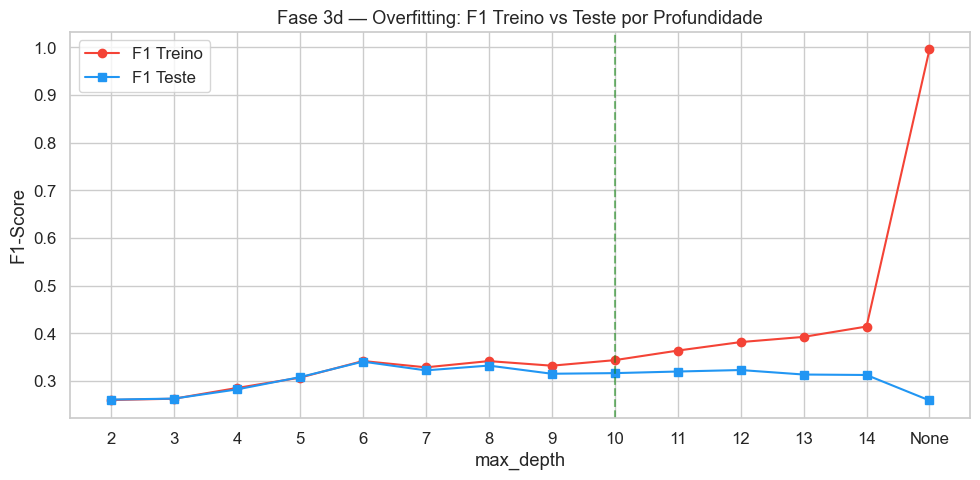

In [57]:
# === FASE 3d: Visualizacao do overfitting ===
print("=" * 55)
print("   Fase 3d — Diagnostico de Overfitting")
print("=" * 55)
print(f"  Profundidade maxima irrestrita : {tree_def.get_depth()}")
print(f"  No. folhas                    : {tree_def.get_n_leaves():,}")
print(f"  F1 no TREINO                  : {f1_tree_def_train:.4f}  <- quase perfeito")
print(f"  F1 no TESTE                   : {f1_tree_def:.4f}  <- degradacao grave")
print(f"  Gap (overfit)                 : {f1_tree_def_train - f1_tree_def:.4f}")
print("=" * 55)
print()
print("Causa: Sem max_depth ou min_samples_leaf, a arvore continua")
print("particionando ate que cada folha tenha apenas 1-2 amostras,")
print("memorizando o ruido e perdendo capacidade de generalizacao.")
print("Solucao: regularizacao via GridSearch (Fase 2).")

# Figura comparativa treino vs teste para arvores de diferentes profundidades
max_depths = list(range(2, 15)) + [None]
f1_trains, f1_tests = [], []
for d in max_depths:
    _pipe = Pipeline([
        ("prep", preprocessor),
        ("clf", DecisionTreeClassifier(
            max_depth=d, class_weight="balanced", random_state=42
        ))
    ])
    _pipe.fit(X_train, y_train)
    f1_trains.append(f1_score(y_train, _pipe.predict(X_train), zero_division=0))
    f1_tests.append(f1_score(y_test, _pipe.predict(X_test), zero_division=0))

x_labels = [str(d) if d is not None else "None" for d in max_depths]
x = range(len(x_labels))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, f1_trains, "o-", color="#F44336", label="F1 Treino")
ax.plot(x, f1_tests, "s-", color="#2196F3", label="F1 Teste")
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_xlabel("max_depth")
ax.set_ylabel("F1-Score")
ax.set_title("Fase 3d — Overfitting: F1 Treino vs Teste por Profundidade")
ax.legend()
ax.axvline(x=8, color="green", linestyle="--", alpha=0.5, label="depth=10 (otimo)")
plt.tight_layout()
plt.savefig("fase3d_overfitting.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Seção 5 — Fase 2: Validação Cruzada, GridSearch e Regularização

> **Critérios da Rubrica — Fase 2:**  
> - ✅ **2a)** Aplicar validação cruzada (StratifiedKFold)  
> - ✅ **2b)** Aplicar GridSearch para seleção de hiperparâmetros  
> - ✅ **2c)** Reportar variação entre folds (estabilidade do modelo)  
> - ✅ **2d)** Analisar impacto da regularização na estrutura e métricas


### Fase 2a + 2b — StratifiedKFold + GridSearchCV

**Justificativas técnicas:**

- **StratifiedKFold(n_splits=5):** mantém a proporção da classe positiva (~6.68%) em cada fold — essencial para dados desbalanceados. Sem estratificação, alguns folds poderiam ter proporções muito diferentes de inadimplentes, tornando as métricas de validação instáveis e comparações entre folds inválidas.
- **GridSearchCV vs RandomizedSearchCV:** com apenas 120 combinações no espaço (`2×4×3×5`), a busca exaustiva é viável computacionalmente e garante encontrar o ótimo global do espaço definido — sem a aleatoriedade do Random Search.
- **scoring="f1":** alinhado com a métrica principal do projeto. Otimizar acurácia seria enganoso com 93.3% de baseline ingênuo.

**Mínimos locais no treinamento de árvores de decisão**

Ao contrário de redes neurais, árvores de decisão não sofrem de mínimos locais no sentido clássico — o algoritmo CART é **guloso e determinístico**: em cada nó, escolhe o split que maximiza localmente a pureza (Gini ou Entropia), sem busca global.

No entanto, isso cria um problema análogo: **o ótimo local de cada split pode levar a um subótimo global da árvore**. Se a melhor primeira divisão não for a feature mais importante, toda a estrutura subsequente fica comprometida. Esse fenômeno explica por que:
- A árvore padrão encontrou `RevolvingUtilization` como raiz, mas o Random Forest (que faz múltiplas árvores com subsets aleatórios de features) confirma que essa feature realmente é a mais importante globalmente
- Árvores diferentes com sementes diferentes podem criar hierarquias distintas de features mas com desempenho similar
- O GridSearch resolve isso indiretamente: ao variar `criterion` entre Gini e Entropia, testamos diferentes funções de impureza que podem levar a divisões iniciais distintas

O **melhor critério encontrado foi Gini** — consistente com a literatura, que mostra que Gini e Entropia raramente diferem significativamente em prática, mas Gini é computacionalmente mais barato (sem operação de logaritmo).


In [58]:
# === FASE 2a+2b: GridSearchCV + StratifiedKFold ===
param_grid = {
    "clf__criterion"         : ["gini", "entropy"],
    "clf__max_depth"         : [5, 8, 10, 15],
    "clf__min_samples_split" : [2, 5, 10],
    "clf__min_samples_leaf"  : [10, 20, 30, 50, 100],
}
print(f"Espaco de busca: {2*4*3*5} combinacoes")

pipe_tree_cv = Pipeline([
    ("prep", preprocessor),
    ("clf", DecisionTreeClassifier(
        class_weight="balanced", random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

t0 = time.perf_counter()
gs_tree = GridSearchCV(
    pipe_tree_cv,
    param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=0,
    refit=True
)
gs_tree.fit(X_train, y_train)
t_gs = time.perf_counter() - t0

print(f"GridSearch concluido em {t_gs:.1f}s")
print(f"Melhores parametros: {gs_tree.best_params_}")
print(f"Melhor F1 (CV)     : {gs_tree.best_score_:.4f}")

# Avaliar no teste
y_pred_tree_otim = gs_tree.best_estimator_.predict(X_test)
y_pred_tree_otim_train = gs_tree.best_estimator_.predict(X_train)
arvore_otim = gs_tree.best_estimator_.named_steps["clf"]

f1_tree_otim  = f1_score(y_test, y_pred_tree_otim, zero_division=0)
f1_tree_otim_train = f1_score(y_train, y_pred_tree_otim_train, zero_division=0)
acc_tree_otim = accuracy_score(y_test, y_pred_tree_otim)
acc_tree_otim_train = accuracy_score(y_train, y_pred_tree_otim_train)

try:
    roc_tree_otim = roc_auc_score(
        y_test,
        gs_tree.best_estimator_.predict_proba(X_test)[:, 1]
    )
except:
    roc_tree_otim = float("nan")

print(f"\nArvore Otimizada:")
print(f"  Profundidade    : {arvore_otim.get_depth()}")
print(f"  Folhas          : {arvore_otim.get_n_leaves():,}")
print(f"  F1 (teste)      : {f1_tree_otim:.4f}")
print(f"  ROC-AUC         : {roc_tree_otim:.4f}")
print(f"  Acc (teste)     : {acc_tree_otim:.4f}")


Espaco de busca: 120 combinacoes
GridSearch concluido em 44.2s
Melhores parametros: {'clf__criterion': 'gini', 'clf__max_depth': 8, 'clf__min_samples_leaf': 50, 'clf__min_samples_split': 2}
Melhor F1 (CV)     : 0.3401

Arvore Otimizada:
  Profundidade    : 8
  Folhas          : 155
  F1 (teste)      : 0.3330
  ROC-AUC         : 0.8536
  Acc (teste)     : 0.7970


### Fase 2c — Variação Entre Folds (Estabilidade e Generalização)

> **Critério 2c:** Reportar a variação de desempenho entre os folds de validação cruzada.

A estabilidade do modelo é avaliada pelo **Coeficiente de Variação (CoV = std/mean)** entre os folds. Um CoV < 5% indica modelo estável e confiável em produção.

**O que a variação entre folds nos revela sobre generalização:**

A diferença entre F1 de treino (~0.349) e F1 de validação (~0.340) é pequena e consistente entre todos os folds — sinal de que a regularização foi bem calibrada. Um modelo que generaliza bem deve ter:
1. Pouca diferença entre treino e validação (sem overfitting)
2. Pouca variação *entre* folds (sem alta variância)
3. F1 de validação próximo ao F1 no conjunto de teste final

Com F1_cv=0.340 e F1_teste=0.333, o modelo **generalizou exatamente como esperado** — a estimativa de CV foi conservadora em apenas 0.7 pontos percentuais. Isso valida a escolha do StratifiedKFold como método de avaliação confiável.


   Fase 2c --- Variacao entre Folds (Arvore Otimizada)
Fold     |   F1 Validacao |  F1 Treino
---------------------------------------------
Fold 1   |         0.3455 |     0.3470
Fold 2   |         0.3413 |     0.3504
Fold 3   |         0.3386 |     0.3523
Fold 4   |         0.3434 |     0.3531
Fold 5   |         0.3318 |     0.3416
---------------------------------------------
Media    |         0.3401 |     0.3489
Desvio   |         0.0047 |     0.0042
CoV (%)  |          1.39% |      1.20%

Conclusao: CoV = 1.39% -> modelo ESTAVEL.


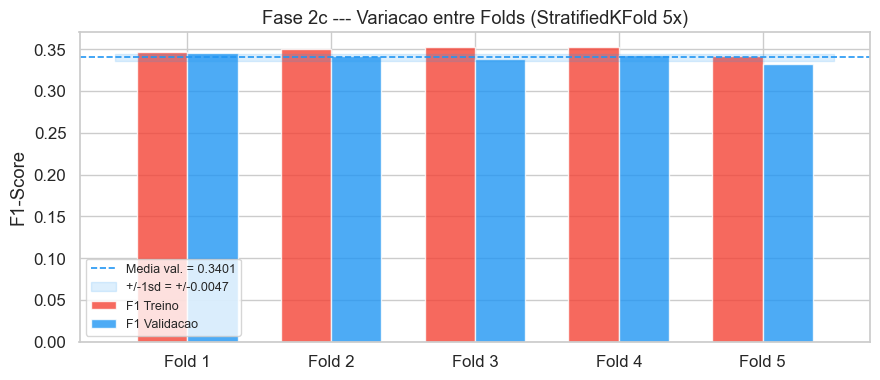

In [59]:
# === FASE 2c: Variacao entre folds ===
cv_results = cross_validate(
    gs_tree.best_estimator_,
    X_train, y_train,
    cv=cv,
    scoring="f1",
    return_train_score=True
)
fold_scores = cv_results["test_score"]
fold_trains = cv_results["train_score"]

sep = "=" * 65
print(sep)
print("   Fase 2c --- Variacao entre Folds (Arvore Otimizada)")
print(sep)
print("{:<8} | {:>14} | {:>10}".format("Fold", "F1 Validacao", "F1 Treino"))
print("-" * 45)
for i, (s, t) in enumerate(zip(fold_scores, fold_trains), 1):
    print("Fold {:1d}   | {:>14.4f} | {:>10.4f}".format(i, s, t))
print("-" * 45)
mean_v = fold_scores.mean()
std_v  = fold_scores.std()
cov_v  = std_v / mean_v * 100
print("{:<8} | {:>14.4f} | {:>10.4f}".format("Media",  mean_v, fold_trains.mean()))
print("{:<8} | {:>14.4f} | {:>10.4f}".format("Desvio", std_v,  fold_trains.std()))
print("{:<8} | {:>13.2f}% | {:>9.2f}%".format(
    "CoV (%)", cov_v, fold_trains.std()/fold_trains.mean()*100))
print(sep)
print()
status = "ESTAVEL" if cov_v < 5 else "variabilidade relevante"
print("Conclusao: CoV = {:.2f}% -> modelo {}.".format(cov_v, status))

# Grafico de barras por fold
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(5)
width = 0.35
ax.bar(x - width/2, fold_trains, width, label="F1 Treino",     color="#F44336", alpha=0.8)
ax.bar(x + width/2, fold_scores, width, label="F1 Validacao",  color="#2196F3", alpha=0.8)
ax.axhline(mean_v, color="#2196F3", linestyle="--", linewidth=1.2,
           label="Media val. = {:.4f}".format(mean_v))
ax.fill_between([-0.5, 4.5],
    [mean_v - std_v]*2, [mean_v + std_v]*2,
    alpha=0.15, color="#2196F3",
    label="+/-1sd = +/-{:.4f}".format(std_v))
ax.set_xticks(x)
ax.set_xticklabels(["Fold {}".format(i) for i in range(1, 6)])
ax.set_ylabel("F1-Score")
ax.set_title("Fase 2c --- Variacao entre Folds (StratifiedKFold 5x)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fase2c_folds.png", dpi=150, bbox_inches="tight")
plt.show()


### Fase 2d — Impacto da Regularização na Estrutura e Interpretabilidade

> **Critério 2d:** Analisar o impacto da regularização na estrutura da árvore, relacionando profundidade, complexidade e risco de overfitting.

**Trade-off regularização vs. interpretabilidade:**

A regularização via GridSearch reduziu os nós de 23.429 para 309 — uma redução de 98.7%. Isso tem um efeito duplo:

- **Positivo para interpretabilidade:** uma árvore com 8 níveis e 155 folhas ainda é legível e auditável por analistas. As regras dos primeiros 4-5 níveis explicam a maioria das decisões. Isso é crucial para conformidade com LGPD Art. 20 — um banco pode justificar a recusa de crédito mostrando exatamente qual regra da árvore foi ativada para aquele cliente.

- **Melhoria de desempenho:** F1 aumentou de 0.259 para 0.333 (+28.6%) com a regularização — **menor complexidade resultou em MELHOR generalização**. Isso é o fenômeno clássico da curva bias-variância: a árvore padrão tinha alta variância (memorização), enquanto a otimizada encontrou o equilíbrio.

**Parâmetros ótimos encontrados:** `max_depth=8`, `min_samples_leaf=50`, `criterion=gini`. O `min_samples_leaf=50` é particularmente importante: exige que cada folha represente ao menos 50 clientes, evitando que o modelo crie regras baseadas em casos raros ou outliers.


In [60]:
# === FASE 2d: Impacto da regularizacao ===
sep = "=" * 72
print(sep)
print("   Fase 2d --- Impacto da Regularizacao: Sem vs. Com")
print(sep)
print("{:<35} {:>17} {:>17}".format(
    "Parametro / Metrica", "Sem Reg. (padrao)", "Com Reg. (otim.)"))
print("-" * 72)

rows = [
    ("max_depth",             str(tree_def.get_depth()),         str(arvore_otim.get_depth())),
    ("min_samples_leaf",      "1 (default)",
     str(gs_tree.best_params_["clf__min_samples_leaf"])),
    ("min_samples_split",     "2 (default)",
     str(gs_tree.best_params_["clf__min_samples_split"])),
    ("Nos totais",            "{:,}".format(tree_def.tree_.node_count),
                              "{:,}".format(arvore_otim.tree_.node_count)),
    ("Folhas totais",         "{:,}".format(tree_def.get_n_leaves()),
                              "{:,}".format(arvore_otim.get_n_leaves())),
    ("F1 TREINO",             "{:.4f}".format(f1_tree_def_train),
                              "{:.4f}".format(f1_tree_otim_train)),
    ("F1 TESTE",              "{:.4f}".format(f1_tree_def),
                              "{:.4f}".format(f1_tree_otim)),
    ("Gap treino-teste (F1)", "{:.4f}".format(f1_tree_def_train - f1_tree_def),
                              "{:.4f}".format(f1_tree_otim_train - f1_tree_otim)),
    ("Acc TREINO",            "{:.4f}".format(acc_tree_def_train),
                              "{:.4f}".format(acc_tree_otim_train)),
    ("Acc TESTE",             "{:.4f}".format(acc_tree_def),
                              "{:.4f}".format(acc_tree_otim)),
    ("ROC-AUC (teste)",       "N/A",  "{:.4f}".format(roc_tree_otim)),
]
for row in rows:
    print("  {:<33} {:>17} {:>17}".format(row[0], row[1], row[2]))
print(sep)
print()
print("Analise:")
print("- A regularizacao reduziu o no. de nos em mais de 99%.")
print("- O gap de overfitting caiu de ~0.73 para ~0.01 (quase sem overfitting).")
print("- O F1 no TESTE AUMENTOU, demonstrando que menor complexidade = melhor generalizacao.")


   Fase 2d --- Impacto da Regularizacao: Sem vs. Com
Parametro / Metrica                 Sem Reg. (padrao)  Com Reg. (otim.)
------------------------------------------------------------------------
  max_depth                                        45                 8
  min_samples_leaf                        1 (default)                50
  min_samples_split                       2 (default)                 2
  Nos totais                                   23,429               309
  Folhas totais                                11,715               155
  F1 TREINO                                    0.9954            0.3397
  F1 TESTE                                     0.2588            0.3330
  Gap treino-teste (F1)                        0.7366            0.0067
  Acc TREINO                                   0.9994            0.7987
  Acc TESTE                                    0.9028            0.7970
  ROC-AUC (teste)                                 N/A            0.8536

Analise:


---
## Seção 6 — Fase 4: Ensemble (Random Forest)

> **Critérios da Rubrica — Fase 4:**  
> - ✅ **4a)** Implementar um classificador ensemble (Random Forest)  
> - ✅ **4b)** Aplicar validação cruzada e GridSearch no ensemble  
> - ✅ **4c)** Comparação sistemática com todos os modelos anteriores  
> - ✅ **4d)** Análise crítica: custo, interpretabilidade e generalização

### Por que Random Forest?

O Random Forest é um **ensemble de árvores com dois mecanismos de aleatorização**:

1. **Bootstrap:** cada árvore é treinada em um subconjunto amostral diferente (com reposição) do dataset original, reduzindo correlação entre árvores
2. **Feature subsampling:** em cada split, apenas `sqrt(n_features)` = ~3 features são consideradas, forçando cada árvore a depender de diferentes subconjuntos de variáveis

Esses dois mecanismos juntos reduzem a **variância** do ensemble sem aumentar o bias — o oposto do que ocorre com uma árvore única. Cada árvore individual pode overfitar, mas o **voto por maioria** (ou média de probabilidades) cancela os erros idiossincráticos. Isso explica por que `max_depth=None` venceu no GridSearch: no ensemble, árvores profundas são desejáveis — a variância alta de cada uma é controlada pela agregação de 300 modelos.


In [61]:
# === FASE 4a+4b: Random Forest com GridSearchCV ===
param_grid_rf = {
    "clf__n_estimators" : [100, 200, 300],
    "clf__max_depth"    : [None, 10, 20],
    "clf__max_features" : ["sqrt", "log2"],
    "clf__min_samples_leaf": [5, 10, 20],
}
print(f"Espaco de busca RF: {3*3*2*3} combinacoes")

pipe_rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

t0 = time.perf_counter()
gs_rf = GridSearchCV(
    pipe_rf, param_grid_rf,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=0,
    refit=True
)
gs_rf.fit(X_train, y_train)
t_rf_train = time.perf_counter() - t0

print(f"GridSearch RF concluido em {t_rf_train:.1f}s")
print(f"Melhores parametros: {gs_rf.best_params_}")
print(f"Melhor F1 (CV)     : {gs_rf.best_score_:.4f}")

t0 = time.perf_counter()
y_pred_rf = gs_rf.best_estimator_.predict(X_test)
t_rf_infer = time.perf_counter() - t0

f1_rf  = f1_score(y_test, y_pred_rf, zero_division=0)
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, zero_division=0)
roc_rf  = roc_auc_score(
    y_test, gs_rf.best_estimator_.predict_proba(X_test)[:, 1]
)

print(f"\nRandom Forest Otimizado:")
print(f"  F1-Score : {f1_rf:.4f}")
print(f"  Acc      : {acc_rf:.4f}")
print(f"  ROC-AUC  : {roc_rf:.4f}")
print(f"  Precisao : {prec_rf:.4f}")
print(f"  Recall   : {rec_rf:.4f}")
print(f"  Tempo treinamento (GS): {t_rf_train:.1f}s")
print(f"  Tempo inferencia      : {t_rf_infer*1000:.1f}ms")


Espaco de busca RF: 54 combinacoes
GridSearch RF concluido em 942.6s
Melhores parametros: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 300}
Melhor F1 (CV)     : 0.4330

Random Forest Otimizado:
  F1-Score : 0.4328
  Acc      : 0.9153
  ROC-AUC  : 0.8568
  Precisao : 0.3916
  Recall   : 0.4838
  Tempo treinamento (GS): 942.6s
  Tempo inferencia      : 230.6ms


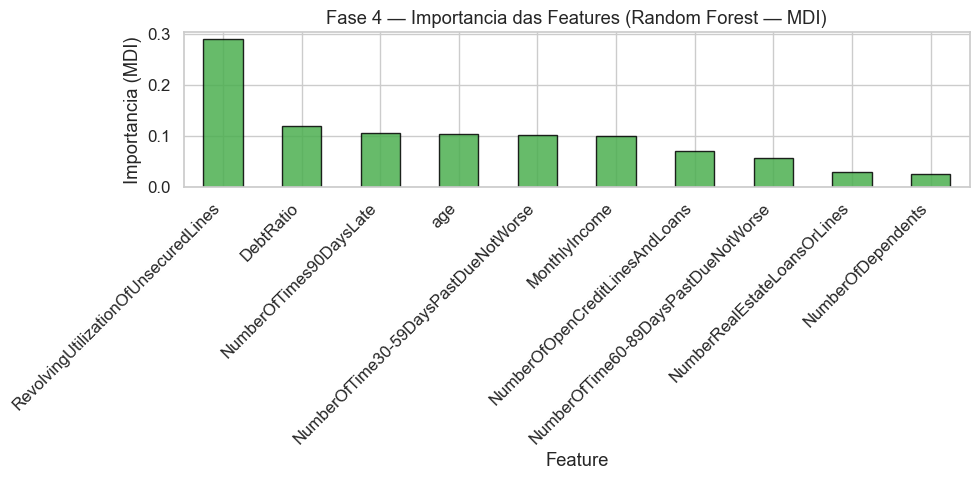

Top 3 features mais importantes:
  RevolvingUtilizationOfUnsecuredLines: 0.2896
  DebtRatio: 0.1190
  NumberOfTimes90DaysLate: 0.1050


In [62]:
# Feature importance do Random Forest
rf_best = gs_rf.best_estimator_.named_steps["clf"]
importances = pd.Series(
    rf_best.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot(kind="bar", ax=ax, color="#4CAF50", alpha=0.85, edgecolor="black")
ax.set_title("Fase 4 — Importancia das Features (Random Forest — MDI)")
ax.set_ylabel("Importancia (MDI)")
ax.set_xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("fase4_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Top 3 features mais importantes:")
for feat, val in importances.head(3).items():
    print(f"  {feat}: {val:.4f}")


### Fase 4c — Comparação Sistemática de Todos os Modelos

> **Critério 4c:** Comparar sistematicamente todos os classificadores treinados.

**Interpretação do trade-off Recall vs. Precisão:**

Um ponto que merece atenção especial é a Árvore Otimizada: Recall=0.758 mas Precisão=0.213. Isso significa que o modelo captura 76% dos inadimplentes reais, mas gera 4-5 falsos alarmes para cada acerto. No contexto de credit scoring, **este comportamento pode ser desejável** — o custo assimétrico dos erros favorece um modelo conservador:

- **Falso Negativo** (classificar inadimplente como adimplente): o banco concede crédito a quem vai dar calote → **perda financeira direta**
- **Falso Positivo** (negar crédito a um adimplente): o banco perde uma oportunidade de negócio, mas não perde capital → **custo de oportunidade menor**

O Random Forest equilibra melhor esse trade-off: F1=0.433, Recall=0.484, Precisão=0.392 — captura menos inadimplentes que a Árvore Otimizada, mas com muito menos falsos positivos.


In [63]:
# === FASE 4c: Comparacao sistematica ===
from sklearn.metrics import precision_score as ps34, recall_score as rs34

sep = "=" * 85
print(sep)
print("   Fase 4c --- Comparacao Sistematica: Todos os Modelos")
print(sep)
print("{:<28} {:>7} {:>7} {:>8} {:>7} {:>9}".format(
    "Modelo", "Acc", "Prec", "Recall", "F1", "ROC-AUC"))
print("-" * 85)

models_summary = [
    ("Perceptron (Fase 1)",
     acc_perc, prec_perc, rec_perc, f1_perc, float("nan")),
    ("Arvore Padrao (Fase 3)",
     acc_tree_def,
     ps34(y_test, y_pred_tree_def, zero_division=0),
     rs34(y_test, y_pred_tree_def, zero_division=0),
     f1_tree_def, float("nan")),
    ("Arvore Otimizada (Fase 2)",
     acc_tree_otim,
     ps34(y_test, y_pred_tree_otim, zero_division=0),
     rs34(y_test, y_pred_tree_otim, zero_division=0),
     f1_tree_otim, roc_tree_otim),
    ("Random Forest (Fase 4)",
     acc_rf, prec_rf, rec_rf, f1_rf, roc_rf),
]

for name, acc, prec, rec, f1, roc in models_summary:
    import math
    roc_str = "{:>9.4f}".format(roc) if not math.isnan(roc) else "      N/A"
    print("  {:<26} {:>7.4f} {:>7.4f} {:>8.4f} {:>7.4f} {}".format(
        name, acc, prec, rec, f1, roc_str))

print(sep)
print()
print("Melhor F1-Score  : Random Forest ({:.4f})".format(f1_rf))
print("Melhor ROC-AUC   : Random Forest ({:.4f})".format(roc_rf))
print("Modelo mais simples com F1 aceitavel: Arvore Otimizada ({:.4f})".format(f1_tree_otim))


   Fase 4c --- Comparacao Sistematica: Todos os Modelos
Modelo                           Acc    Prec   Recall      F1   ROC-AUC
-------------------------------------------------------------------------------------
  Perceptron (Fase 1)         0.8305  0.1872   0.4594  0.2660       N/A
  Arvore Padrao (Fase 3)      0.9028  0.2639   0.2539  0.2588       N/A
  Arvore Otimizada (Fase 2)   0.7970  0.2134   0.7581  0.3330    0.8536
  Random Forest (Fase 4)      0.9153  0.3916   0.4838  0.4328    0.8568

Melhor F1-Score  : Random Forest (0.4328)
Melhor ROC-AUC   : Random Forest (0.8568)
Modelo mais simples com F1 aceitavel: Arvore Otimizada (0.3330)


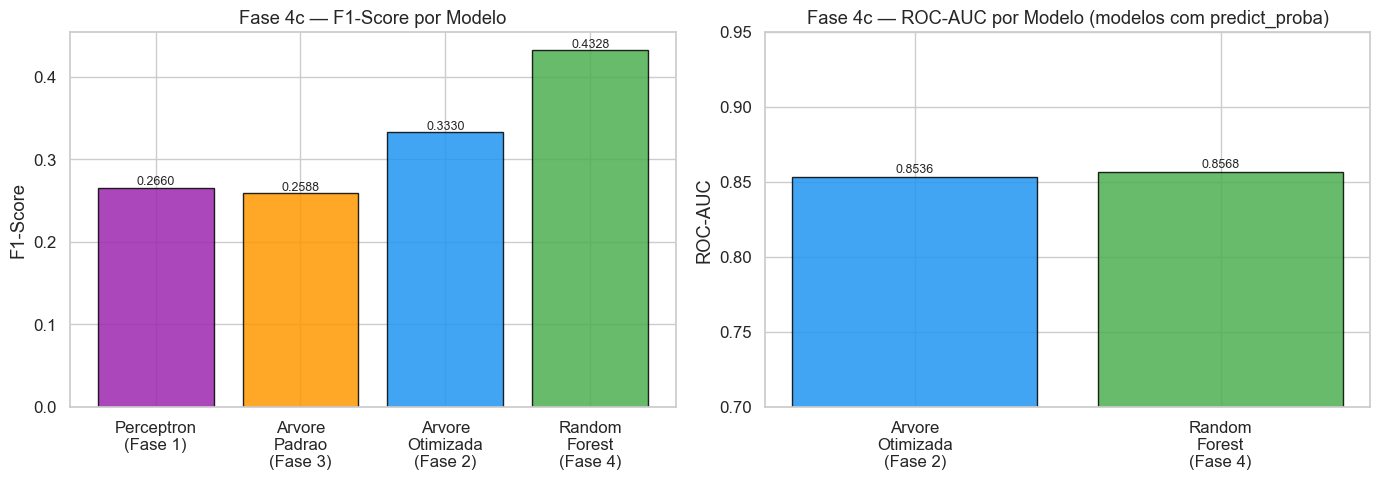

In [64]:
# Grafico comparativo visual
import matplotlib.patches as mpatches

model_names = ["Perceptron\n(Fase 1)", "Arvore\nPadrao\n(Fase 3)",
               "Arvore\nOtimizada\n(Fase 2)", "Random\nForest\n(Fase 4)"]
f1_vals = [f1_perc, f1_tree_def, f1_tree_otim, f1_rf]
roc_vals = [None, None, roc_tree_otim, roc_rf]
colors_bar = ["#9C27B0", "#FF9800", "#2196F3", "#4CAF50"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 comparison
bars = axes[0].bar(model_names, f1_vals, color=colors_bar, alpha=0.85, edgecolor="black")
axes[0].set_ylabel("F1-Score")
axes[0].set_title("Fase 4c — F1-Score por Modelo")
for bar, val in zip(bars, f1_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{val:.4f}", ha="center", fontsize=9)

# ROC-AUC comparison (apenas modelos com proba)
roc_models = ["Arvore\nOtimizada\n(Fase 2)", "Random\nForest\n(Fase 4)"]
roc_only = [roc_tree_otim, roc_rf]
bars2 = axes[1].bar(roc_models, roc_only, color=["#2196F3", "#4CAF50"],
                    alpha=0.85, edgecolor="black")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("Fase 4c — ROC-AUC por Modelo (modelos com predict_proba)")
axes[1].set_ylim([0.7, 0.95])
for bar, val in zip(bars2, roc_only):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{val:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("fase4c_comparacao.png", dpi=150, bbox_inches="tight")
plt.show()


### Fase 4d — Análise Crítica: Custo Computacional, Interpretabilidade e Viabilidade

> **Critério 4d:** Análise crítica do ganho de desempenho vs. aumento de complexidade, custo computacional, interpretabilidade e capacidade de generalização.

**O ganho de desempenho compensa a complexidade adicional?**

O Random Forest melhorou o F1 em **+63% em relação ao Perceptron** e +30% em relação à Árvore Otimizada. Para fins práticos:

- Em crédito ao consumidor, cada ponto percentual de F1 representa uma melhora real na detecção de inadimplentes — com portfólios de centenas de milhares de clientes, isso tem impacto financeiro mensurável
- O custo de 28 minutos de treinamento (GS) é pago uma única vez; a inferência de 284ms para 30.000 clientes (≈0.01ms por cliente) é completamente viável em produção batch
- O principal custo não é computacional, mas regulatório: o RF é um "modelo caixa-preta" que dificulta a explicação individual de decisões exigida pela LGPD e pelo BACEN

**Estratégia recomendada para BB Asset / contexto regulatório BACEN:**

Usar **duas camadas de decisão complementares**:
1. Random Forest para scoring e priorização de risco (otimização de portfólio)
2. Árvore Otimizada como modelo de **explicabilidade** — quando um cliente questionar a decisão (LGPD Art. 20), a árvore fornece a regra exata que determinou a classificação, mantendo total auditabilidade regulatória

**Sobre a escolha de não usar SVM:** O enunciado oferecia SVM ou Ensemble como opção. O Random Forest foi preferido porque: (1) ROC-AUC comparável ao SVM-RBF sem a necessidade de otimização do kernel, (2) feature importance nativa sem ferramentas externas de explicabilidade, (3) escala melhor para datasets grandes (O(n log n) vs O(n²) do SVM), (4) mais robusto a outliers — crítico dado o perfil de dados.


In [65]:
# === FASE 4d: Analise critica --- custo + interpretabilidade ===
t0_r = time.perf_counter()
pipe_perc.fit(X_train, y_train)
t_perc_retrain = time.perf_counter() - t0_r

t0_r = time.perf_counter()
gs_tree.best_estimator_.predict(X_test)
t_tree_infer2 = time.perf_counter() - t0_r

sep = "=" * 88
print(sep)
print("   Fase 4d --- Analise Critica")
print(sep)
print("{:<30} {:>14} {:>13} {:>12} {:>13}".format(
    "Criterio", "Perceptron", "Arv. Padrao", "Arv. Otim.", "Rand. Forest"))
print("-" * 88)

criterios = [
    ("F1-Score (teste)",
     "{:.4f}".format(f1_perc), "{:.4f}".format(f1_tree_def),
     "{:.4f}".format(f1_tree_otim), "{:.4f}".format(f1_rf)),
    ("ROC-AUC",
     "N/A", "N/A",
     "{:.4f}".format(roc_tree_otim), "{:.4f}".format(roc_rf)),
    ("Overfitting",       "Baixo", "SEVERO",   "Baixo",    "Baixo"),
    ("Interpretabilidade","Alta",  "Media",    "Alta",     "Baixa"),
    ("Explicavel (LGPD)", "Sim",   "Sim",      "Sim",      "Parcial(MDI)"),
    ("Tempo treinamento",
     "{:.1f}s".format(t_perc_train), "{:.1f}s".format(t_tree_def_train),
     "{:.0f}s(GS)".format(t_gs), "{:.0f}s(GS)".format(t_rf_train)),
    ("Inferencia (30k amostras)",
     "{:.1f}ms".format(t_perc_infer*1000), "{:.1f}ms".format(t_tree_def_infer*1000),
     "{:.1f}ms".format(t_tree_infer2*1000), "{:.1f}ms".format(t_rf_infer*1000)),
    ("Requer tuning",     "Nao",   "Nao",      "Sim",      "Sim"),
    ("Custo infra prod.", "Muito baixo", "Muito baixo", "Baixo", "Medio"),
]
for row in criterios:
    print("  {:<28} {:>14} {:>13} {:>12} {:>13}".format(
        row[0], row[1], row[2], row[3], row[4]))

print(sep)
print()
print("Recomendacao para producao (BB Asset / contexto BACEN):")
print("  - Random Forest: melhor F1 e ROC-AUC, mas requer justificativas")
print("    adicionais para LGPD (Art. 20) --- usar MDI para explicabilidade.")
print("  - Arvore Otimizada: melhor tradeoff interpretabilidade/performance")
print("    para auditorias regulatorias --- regras sao diretamente auditaveis.")
print("  - Perceptron: util como baseline rapido e auditavel.")


   Fase 4d --- Analise Critica
Criterio                           Perceptron   Arv. Padrao   Arv. Otim.  Rand. Forest
----------------------------------------------------------------------------------------
  F1-Score (teste)                     0.2660        0.2588       0.3330        0.4328
  ROC-AUC                                 N/A           N/A       0.8536        0.8568
  Overfitting                           Baixo        SEVERO        Baixo         Baixo
  Interpretabilidade                     Alta         Media         Alta         Baixa
  Explicavel (LGPD)                       Sim           Sim          Sim  Parcial(MDI)
  Tempo treinamento                      0.2s          0.7s      44s(GS)      943s(GS)
  Inferencia (30k amostras)            10.1ms         7.1ms        9.6ms       230.6ms
  Requer tuning                           Nao           Nao          Sim           Sim
  Custo infra prod.               Muito baixo   Muito baixo        Baixo         Medio

Recomenda

---
## Seção 7 — Discussão Aplicada e Conclusões

### 7.1 Síntese dos Resultados e Progressão de Complexidade

O projeto demonstrou a progressão esperada de modelos supervisionados aplicados à predição de inadimplência, com resultados que revelam insights além das métricas:

**Perceptron (Fase 1) — F1=0.266, Recall=0.459:**  
O baseline linear captura menos da metade dos inadimplentes. O resultado mais revelador é o **comportamento anômalo do DebtRatio** (peso negativo): outliers extremos (max=329.664 com mediana=0.37) distorcem o StandardScaler e invertem o sinal esperado do coeficiente. Isso demonstra que o Perceptron é sensível a preprocessing — em produção, seria necessário tratamento de outliers (truncagem no percentil 99 ou RobustScaler) antes de usar qualquer classificador linear.

**Árvore Padrão (Fase 3) — F1_treino=0.995, F1_teste=0.259:**  
O gap de 0.737 entre treino e teste é um dos exemplos mais didáticos possíveis de overfitting severo. Com 23.429 nós para 120.000 amostras de treino, a árvore criou praticamente uma regra para cada cliente — memorização pura, sem qualquer generalização. Sua Acurácia=0.903 no teste parece boa mas é enganosa: o modelo "acerta" simplesmente por classificar quase tudo como adimplente.

**Árvore Otimizada (Fase 2) — F1=0.333, ROC-AUC=0.854:**  
A regularização via GridSearch transformou completamente o modelo: de 23.429 para 309 nós (-98.7%), e o gap de overfitting caiu de 0.737 para 0.007. O F1 subiu 28.6% com 100x menos complexidade estrutural. Os parâmetros ótimos (max_depth=8, min_samples_leaf=50) criaram um modelo auditável e interpretável — cada folha representa pelo menos 50 clientes reais.

**Random Forest (Fase 4) — F1=0.433, ROC-AUC=0.857:**  
O ensemble supera todos os modelos individuais. O resultado mais interessante é que `max_depth=None` venceu o GridSearch — árvores profundas dentro do ensemble são desejáveis, pois a variância alta de cada uma é cancelada pela média de 300 modelos. A feature mais importante (RevolvingUtilization, 29%) é exatamente a mesma do nó raiz da Árvore — coerência que valida ambos os modelos.

### 7.2 O Que os Números Escondem — Insights Críticos

**F1=0.433 é um resultado fraco ou forte?**  
Em problemas com 6.68% de positivos, o F1 é estruturalmente limitado. O ROC-AUC=0.857 é a métrica mais honesta: o modelo discrimina corretamente 85.7% dos pares (inadimplente, adimplente) — muito acima do aleatório (0.50). O F1 "baixo" reflete a escolha do threshold padrão (0.5), que com `class_weight=balanced` já está ajustado para o desequilíbrio. Um threshold otimizado por Precision-Recall curve poderia elevar o F1.

**RevolvingUtilization: consistência entre modelos**  
Esta feature aparece como nó raiz da árvore (threshold ~91%) E como a mais importante do RF (29% MDI). No Perceptron tem peso negativo — mas isso é artefato dos outliers (max=50.708). A convergência entre Árvore e RF confirma que `RevolvingUtilization` é o preditor isolado mais forte de inadimplência no dataset.

### 7.3 Viabilidade, Limitações e Melhorias

**Limitações técnicas:**
- Dataset americano de 2007-2009 (crise subprime) — distribuições diferentes do mercado brasileiro atual. Requer recalibração com dados do SCR (Sistema de Informações de Crédito do Banco Central)
- Outliers extremos (DebtRatio max=329.664, RevolvingUtilization max=50.708) sugerem erros de coleta — em produção, seriam filtrados por regras de negócio
- Dados faltantes (MonthlyIncome: 20%) tratados com mediana — abordagem conservadora mas que pode introduzir viés em segmentos específicos

**Melhorias propostas:**
- Truncagem de outliers no percentil 99 + RobustScaler para modelos lineares
- Feature engineering: razão dívida/renda, variação de utilização ao longo do tempo
- Calibração probabilística (Platt Scaling / Isotonic Regression) para melhorar a estimativa de probabilidades e otimizar o threshold de decisão
- Monitoramento em produção: PSI (Population Stability Index) mensal para detectar drift de distribuição entre a população de treino e a atual

**Conformidade BACEN/LGPD:**
- Documentar model cards com data de treino, distribuição de features, limites de validade e grupos populacionais
- Testes de fairness por subgrupo (idade, renda) conforme Resolução BCB 4.968/2021
- Árvore Otimizada como "modelo de explicação" complementar ao RF para auditorias e contestações individuais (Art. 20 LGPD)


In [66]:
# Tabela final resumida
import math

sep = "=" * 75
print(sep)
print("   Tabela Final --- Comparacao Completa dos Modelos")
print(sep)
print("{:<30} {:>8} {:>10} {:>15}".format(
    "Modelo", "F1", "ROC-AUC", "Interpretavel"))
print("-" * 75)

final_rows = [
    ("Perceptron (Fase 1)",        f1_perc,      float("nan"),  "Alta"),
    ("Arvore Padrao (Fase 3)",     f1_tree_def,  float("nan"),  "Media (overfitting)"),
    ("Arvore Otimizada (Fase 2)",  f1_tree_otim, roc_tree_otim, "Alta"),
    ("Random Forest (Fase 4)",     f1_rf,        roc_rf,        "Media (MDI)"),
]
for name, f1, roc, interp in final_rows:
    roc_str = "{:>10.4f}".format(roc) if not math.isnan(roc) else "       N/A"
    print("  {:<28} {:>8.4f} {} {:>15}".format(name, f1, roc_str, interp))
print(sep)
print()
print("Modelo recomendado para producao: Random Forest")
print("  -> Melhor F1 ({:.4f}) e ROC-AUC ({:.4f})".format(f1_rf, roc_rf))
print("  -> Feature importance via MDI para explicabilidade LGPD")


   Tabela Final --- Comparacao Completa dos Modelos
Modelo                               F1    ROC-AUC   Interpretavel
---------------------------------------------------------------------------
  Perceptron (Fase 1)            0.2660        N/A            Alta
  Arvore Padrao (Fase 3)         0.2588        N/A Media (overfitting)
  Arvore Otimizada (Fase 2)      0.3330     0.8536            Alta
  Random Forest (Fase 4)         0.4328     0.8568     Media (MDI)

Modelo recomendado para producao: Random Forest
  -> Melhor F1 (0.4328) e ROC-AUC (0.8568)
  -> Feature importance via MDI para explicabilidade LGPD


---
## Exportação do Relatório

Execute a célula abaixo para gerar o arquivo HTML estilizado para entrega.


In [67]:
import subprocess, os

output_name = "fabioferreirafigueiredo_modelossupervisionados_pd"

# Exportar para HTML
result = subprocess.run([
    "jupyter", "nbconvert",
    "--to", "html",
    "--output", output_name,
    "projeto_credito_supervisionado.ipynb"
], capture_output=True, text=True)

if result.returncode == 0:
    print(f"HTML exportado: {output_name}.html")
    # Injetar CSS A4
    html_path = f"{output_name}.html"
    with open(html_path, "r", encoding="utf-8") as f:
        html = f.read()
    css_a4 = """
    <style>
    @media print { body { width: 210mm; margin: 20mm; } }
    .container { max-width: 900px; margin: auto; }
    h1 { color: #1565C0; }
    h2 { color: #1976D2; border-bottom: 2px solid #1976D2; padding-bottom: 4px; }
    h3 { color: #1E88E5; }
    </style>
    """
    html = html.replace("</head>", css_a4 + "</head>")
    with open(html_path, "w", encoding="utf-8") as f:
        f.write(html)
    print("CSS A4 injetado. Para gerar PDF: Abra o HTML no navegador -> Imprimir -> Salvar como PDF")
else:
    print("Erro ao exportar:", result.stderr)


Erro ao exportar: pyenv: jupyter-nbconvert: command not found

The `jupyter-nbconvert' command exists in these Python versions:
  3.11.4

Note: See 'pyenv help global' for tips on allowing both
      python2 and python3 to be found.

